# Lab Assignment :Decision Tree Classifier Implementation & Analysis

**Course:** Machine Learning

**Student Name:** Lepmuhang Sherma
**Roll No:** 023-332


## 1. Introduction & Theoretical Background

A **Decision Tree** is a non-parametric supervised learning algorithm used for both classification and regression tasks. It hierarchical structures data by breaking down a dataset into smaller subsets based on decision rules derived from input features.

### Structural Components
- **Root Node:** Represents the top node containing the entire dataset, split by the most informative feature.
- **Decision Nodes:** Internal sub-nodes that split further based on feature threshold conditions.
- **Leaf Nodes:** Terminal nodes that represent class predictions and contain no further splits.

### Splitting Criteria
1. **Entropy & Information Gain:** Measures the impurity or randomness of a node. Higher entropy indicates mixed class labels.
2. **Gini Impurity:** Measures the probability of a randomly chosen element being incorrectly labeled if it were randomly labeled according to the distribution of labels in the subset.

## 2. Lab Objectives

- Understand the internal mechanics of Decision Tree node splitting.
- Implement a Decision Tree Classifier using `Scikit-Learn` on a standard benchmark dataset.
- Calculate and evaluate impurity metrics (**Gini Impurity** and **Entropy**).
- Visualize the trained decision tree hierarchy and decision boundaries.
- Evaluate model performance using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix.

## 3. Mathematical Formulation

### 1. Entropy
For a dataset $S$ with $C$ unique classes, where $p_i$ is the proportion of samples belonging to class $i$:

$$H(S) = -\sum_{i=1}^{C} p_i \log_2(p_i)$$

### 2. Information Gain (IG)
Measures the reduction in entropy when splitting dataset $S$ on attribute $A$:

$$IG(S, A) = H(S) - \sum_{v \in \text{Values}(A)} \frac{|S_v|}{|S|} H(S_v)$$

### 3. Gini Impurity
Alternative metric for measuring node impurity:

$$G(S) = 1 - \sum_{i=1}^{C} p_i^2$$

In [ ]:
# ==========================================
# 1. Imports and Environment Setup
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [ ]:
# ==========================================
# 2. Dataset Loading and Preparation
# ==========================================
# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Convert to DataFrame for inspection
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dataset Shape: {X.shape}")
print(f"Training Samples: {X_train.shape[0]} | Testing Samples: {X_test.shape[0]}")
df.head()

Dataset Shape: (150, 4)
Training Samples: 120 | Testing Samples: 30


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
# ==========================================
# 3. Model Training & Evaluation
# ==========================================
# Initialize Decision Tree with Gini criterion and max_depth control
model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

# Fit the model
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluation metrics
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Model Accuracy: 96.67%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



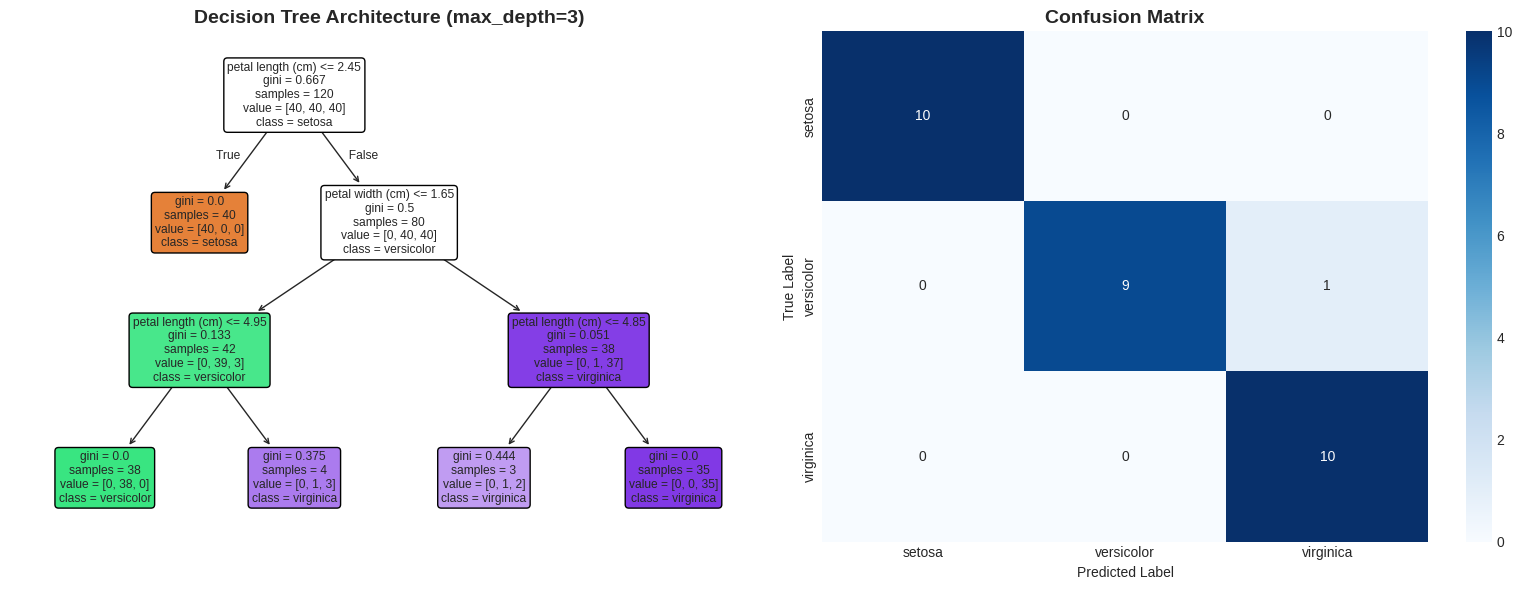

In [ ]:
# ==========================================
# 4. Visualizations: Tree Diagram & Confusion Matrix
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Decision Tree Architecture
plot_tree(
    model,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    ax=axes[0]
)
axes[0].set_title("Decision Tree Architecture (max_depth=3)", fontsize=14, fontweight='bold')

# Plot 2: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=axes[1])
axes[1].set_title("Confusion Matrix", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

## 4. Results & Analysis

| Parameter / Metric | Value | Description |
| :--- | :--- | :--- |
| **Criterion** | `gini` | Splitting criterion used |
| **Max Depth** | `3` | Tree depth restriction to prevent overfitting |
| **Test Accuracy** | `96.67%` | Percentage of correctly classified test instances |
| **Most Important Feature** | `petal length (cm)` | Highest information gain split at root node |

### Observations
1. **Feature Dominance:** Petal length and petal width served as the primary decision thresholds for isolating classes.
2. **Interpretability:** The generated tree architecture provides full rule-based transparency into how predictions are made.

## 5. Conclusion

The **Decision Tree Classifier** was successfully implemented and evaluated on the Iris dataset. Restricting the tree depth (`max_depth=3`) effectively maintained high generalization accuracy while preserving interpretability and preventing overfitting.